<a href="https://colab.research.google.com/github/NAMU578/INFSUB/blob/main/notebooks/3_%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%9D%B4%ED%95%B4(%EC%98%88%EC%A0%9C).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 아이리스(붓꽃) 분류
붓꽃에 대해 4가지 측정값(꽃잎의 길이와 너비, 꽃받침의 길이와 너비)을 이용하여 3가지 품종(Setosa, Versicolor, Virginica)을 예측하는 가장 대표적인 머신러닝 지도학습 예제<br>
<img src="https://drive.google.com/uc?id=1qz9DRlUJrX1tQsRrBL_4e98qXj4UQ2oY" height=234 width=400>

<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_591/2044453571.py:19: SyntaxWarning: invalid escape sequence '\o'
  plt.colorbar(contour, label='vorticity ($\omega$)')


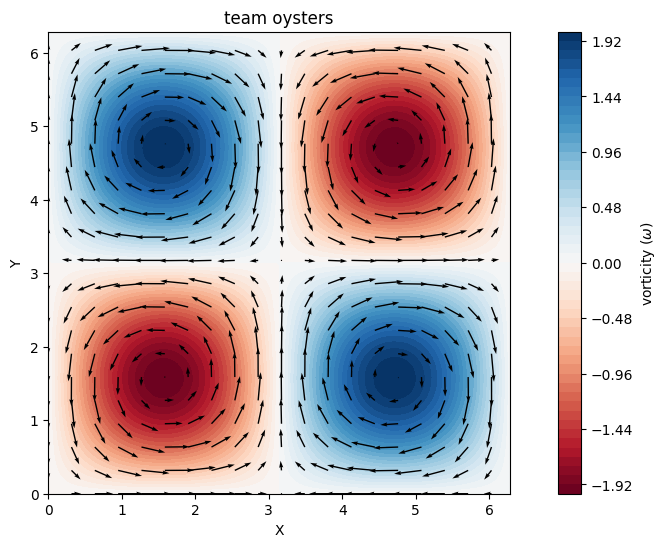

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 격자 데이터 생성 (0부터 2*pi 영역)
x = np.linspace(0, 2 * np.pi, 100)
y = np.linspace(0, 2 * np.pi, 100)
X, Y = np.meshgrid(x, y)

# 2. 테일러-그린 와류의 수학적 물리 공식 정의 (시간 t=0 기준)
u =  np.sin(X) * np.cos(Y)  # x축 방향 속도
v = -np.cos(X) * np.sin(Y)  # y축 방향 속도
vorticity = -2 * np.sin(X) * np.sin(Y)  # 와도 (Vorticity)

# 3. 그래프 그리기
plt.figure(figsize=(8, 6))

# 배경: 와도의 강도를 나타내는 컨투어 맵 (수치가 클수록 강한 회전)
contour = plt.contourf(X, Y, vorticity, cmap='RdBu', levels=50)
plt.colorbar(contour, label='vorticity ($\omega$)')

# 화살표: 격자 간격을 넓혀 유체의 흐름(속도 벡터) 표시
skip = 5
plt.quiver(X[::skip, ::skip], Y[::skip, ::skip],
           u[::skip, ::skip], v[::skip, ::skip],
           color='black', scale=15, width=0.003)

# 그래프 서식 설정
plt.title('team oysters')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('scaled')
plt.show()


## 1.csv 파일 형태의 데이터셋을 이용한 머신러닝

In [ ]:
# ============================================
# 1단계: iris.csv 파일 준비 → 코랩에 저장 → pandas로 열기
# ============================================
import pandas as pd

from google.colab import files
uploaded = files.upload()   # 파일 선택 버튼 클릭 → 다운로드 폴더의 iris.csv 선택

# pandas DataFrame으로 열기
df = pd.read_csv('iris.csv')

print("데이터 크기(행, 열):", df.shape)
#df.head()   # 앞 5개 행 미리보기
df.tail()   # 뒤 5개 행 미리보기


Saving iris.csv to iris.csv
데이터 크기(행, 열): (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [ ]:
# 데이터에 결측치가 있는지 확인
# 만약 결측치가 있다면 어떻게 처리할 지 고민해야 함.
print("=== 결측치 개수 확인 ===")
print(df.isnull().sum())

=== 결측치 개수 확인 ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [ ]:
# sum 없으면?
print("=== 결측치 개수 확인 ===")
print(df.isnull())

=== 결측치 개수 확인 ===
     sepal_length  sepal_width  petal_length  petal_width  species
0           False        False         False        False    False
1           False        False         False        False    False
2           False        False         False        False    False
3           False        False         False        False    False
4           False        False         False        False    False
..            ...          ...           ...          ...      ...
145         False        False         False        False    False
146         False        False         False        False    False
147         False        False         False        False    False
148         False        False         False        False    False
149         False        False         False        False    False

[150 rows x 5 columns]


# 📊 데이터 시각화 주요 함수

| 함수              | 설명                                 | 주요 용도            |
| --------------- | ---------------------------------- | ---------------- |
| `figure()`      | 그래프를 그릴 전체 도화지(Figure)의 크기와 형태를 설정 | 그래프 크기 설정        |
| `subplot()`     | 하나의 Figure를 여러 영역으로 나누어 여러 그래프를 배치 | 여러 그래프 비교        |
| `boxplot()`     | 데이터의 중앙값, 분포, 사분위수, 이상치를 보여줌       | 그룹별 분포 비교        |
| `pairplot()`    | 여러 변수의 모든 조합에 대한 관계를 한 번에 보여줌      | 변수 간 관계·상관관계 파악  |
| `heatmap()`     | 값을 색의 농도로 표현하여 크기나 관계를 쉽게 비교       | 상관관계 행렬 시각화      |
| `histplot()`    | 데이터가 각 구간에 얼마나 분포하는지 막대그래프로 표현     | 데이터 분포 확인        |
| `scatterplot()` | 두 변수의 관계를 점으로 표현                   | 두 변수의 상관관계·경향 확인 |
| `countplot()`   | 각 범주에 포함된 데이터의 개수를 막대그래프로 표현       | 범주별 데이터 개수 비교    |

### 🔹 주요 함수 예시

```python
plt.figure(figsize=(8, 5))
```

→ 그래프 전체 크기를 설정 가로 8,세로 5

```python
plt.subplot(2, 2, 1)
```

→ 2행 × 2열로 나눈 공간 중 1번째 위치에 그래프를 배치. 0번째가 없음에 주의

```python
sns.boxplot(data=df, x='species', y='petal_length')
```

→ df의 종(species)별 `petal_length`의 분포와 이상치를 비교

```python
sns.pairplot(df, hue='species')
```

→ 여러 변수 사이의 관계를 한 번에 확인 hue -> species의 각 값마다 색으로 구분

```python
sns.heatmap(df.corr(), annot=True)
```

→ 변수 사이의 상관계수=corr, (-1~1)를 색과 숫자로 표현, annot:주석(annotation)

```python
sns.histplot(data=df, x='sepal_length')
```

→ `sepal_length`의 데이터 분포를 확인

```python
sns.scatterplot(data=df, x='sepal_length', y='petal_length')
```

→ `sepal_length`와 `petal_length`의 관계를 확인

```python
sns.countplot(data=df, x='species')
```

→ 각 `species`에 데이터가 몇 개씩 있는지 확인

### 📌 핵심 정리

**`figure()` → 전체 도화지 설정**
**`subplot()` → 여러 그래프 배치**
**`boxplot()` → 분포·이상치 비교**
**`pairplot()` → 여러 변수의 관계 확인**
**`heatmap()` → 값을 색으로 표현**
**`histplot()` → 데이터 분포 확인**
**`scatterplot()` → 두 변수의 관계 확인**
**`countplot()` → 범주별 개수 비교**


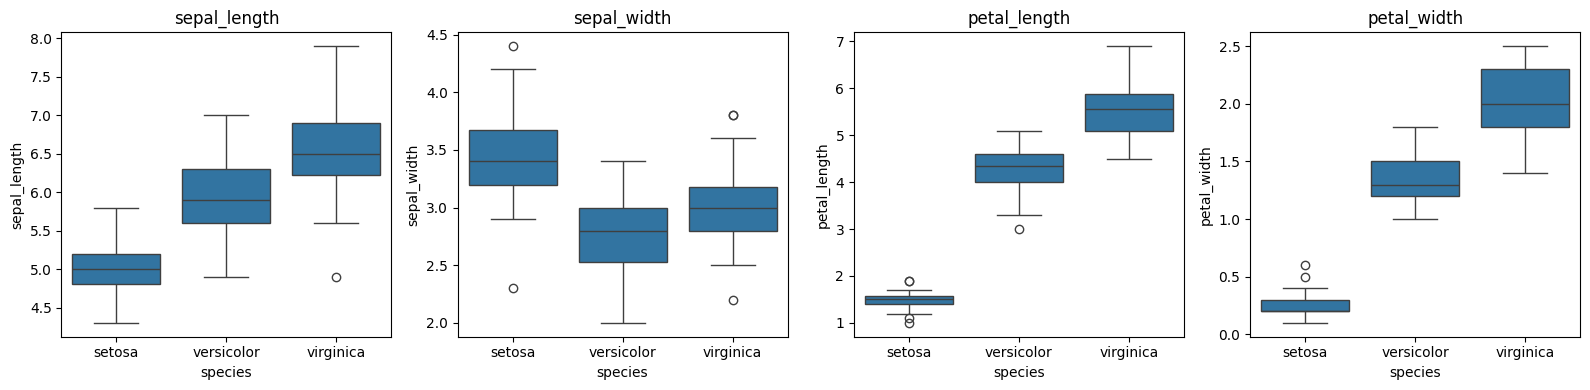

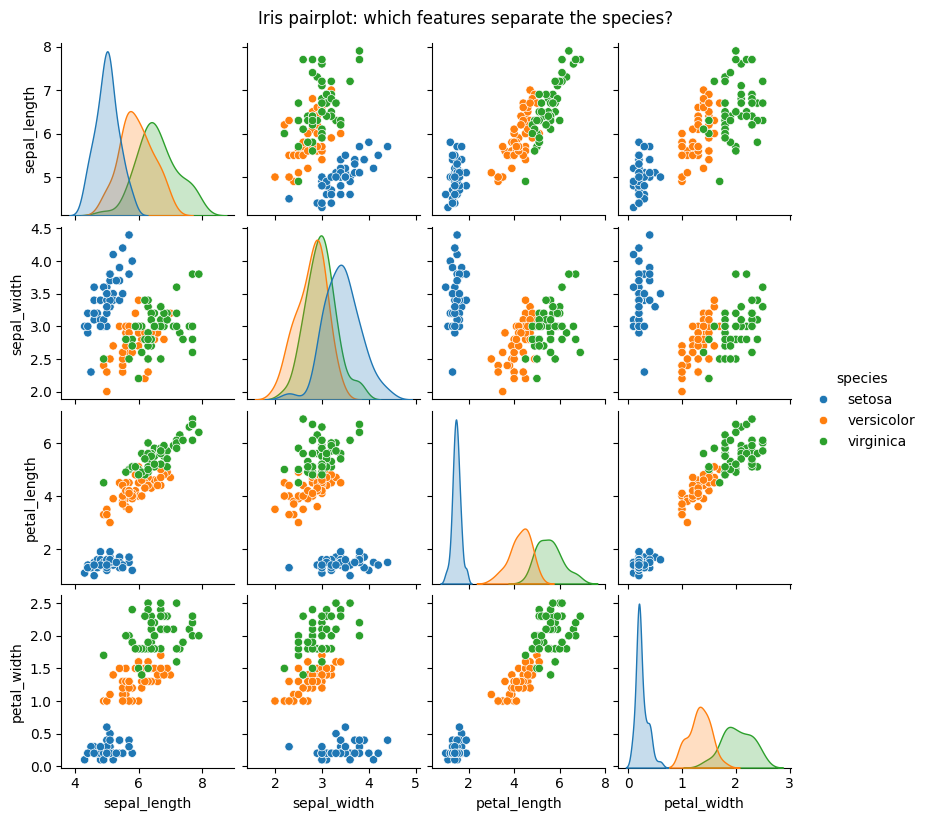

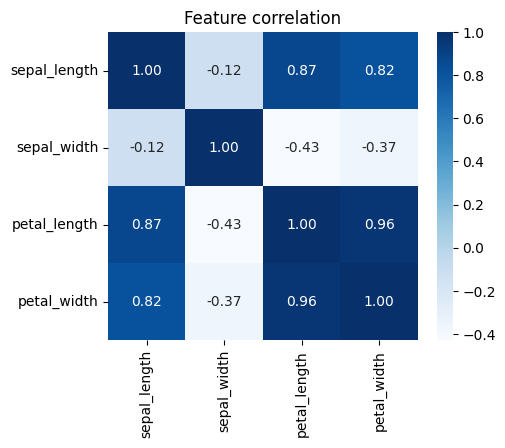

In [ ]:
# ============================================
# 2단계(계속): 특성 분석 시각화
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

# (1) 특성별 박스플롯: 품종 간 분포 차이 + 이상치 확인
fig, axes = plt.subplots(1, 4, figsize=(16, 4)) #1행 4열로, 전체 가로16인치*세로4인치로 그래프 생성, fig:전체 캔버스, axes:각각의 그래프 공간 4개가 든 배열
for ax, col in zip(axes, ['sepal_length','sepal_width','petal_length','petal_width']): #zip:여러 리스트에서, 같은 위치에 있는 값끼리 묶어줌. [1,2,3,4] [a,b,c,d] -> (1, 'a') ~~
    sns.boxplot(data=df, x='species', y=col, ax=ax) #df(불러온데이터)에서, species가 x, col(speal_length~~)가 y축으로 ax(위치)=axes[0], axes[1] ~~ 위치에 그래프
    ax.set_title(col) #각 ax위치의 그래프 제목을 해당 y축으로 설정
plt.tight_layout() #여백 조절
plt.show() #이렇게 만든 그래프를 화면에 출력

# (2) 산점도 행렬: 어떤 특성 조합이 품종을 잘 구분하는가?
sns.pairplot(df, hue='species', height=2.0)
plt.suptitle('Iris pairplot: which features separate the species?', y=1.02)
plt.show()

# (3) 상관계수 히트맵
plt.figure(figsize=(5, 4))
sns.heatmap(df.drop(columns='species').corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Feature correlation'); plt.show()

## 상관관계 히트맵 코드 분석

```python
sns.heatmap(df.drop(columns='species').corr(), annot=True, cmap='Blues', fmt='.2f')
```

`seaborn`으로 DataFrame의 **숫자형 특성 간 상관 행렬**을 히트맵으로 시각화하는 코드.

---

### 1. 데이터 전처리

| 구문 | 역할 |
|---|---|
| `df.drop(columns='species')` | 범주형 타겟 변수인 `species` 컬럼 제거 |
| `.corr()` | 남은 숫자형 컬럼들의 **쌍별 상관계수 행렬** 계산 |

> 상관관계는 숫자형 변수 사이에서만 정의되므로, 범주형 컬럼을 먼저 제외.

---

### 2. 시각화 인자

- **`annot=True`** — 각 셀에 상관계수 값을 숫자로 표기(주석)
- **`cmap='Blues'`** — 파란색 계열 그라데이션 팔레트 (진할수록 강한 양의 상관)
- **`fmt='.2f'`** — 표시되는 숫자를 소수점 둘째 자리까지 포맷

---

### 3. 참고

피어슨 상관계수는 다음과 같이 정의.

$$r_{xy} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2}\sqrt{\sum (y_i - \bar{y})^2}}$$

값의 범위는 $-1 \le r \le 1$ 이며, 대각 성분은 항상 $1$ 입니다.

★ 테스트 정확도: 0.9000

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



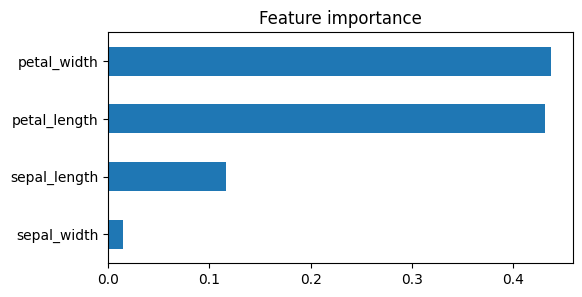

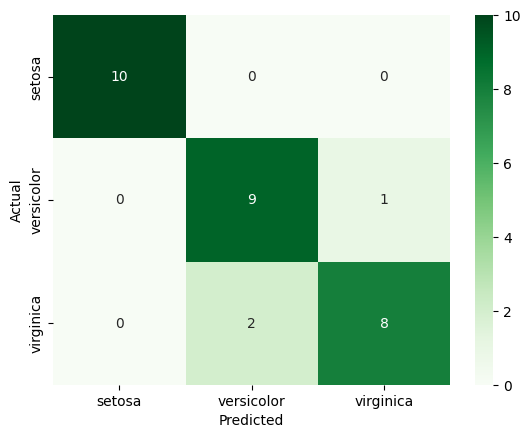

In [ ]:
# ============================================
# 3단계: 모델 선택 → 학습 → 정확도 평가
# ============================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 특성(X)과 정답(y) 분리
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

# 훈련:테스트 = 8:2 분할 (stratify=y : 품종 비율을 유지하며 분할)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 랜덤 포레스트 모델 학습
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 정확도 평가
y_pred = model.predict(X_test)
print(f"★ 테스트 정확도: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

# 특성 중요도 → 그래프 분석 결과와 일치하는지 확인!
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values()
importance.plot(kind='barh', figsize=(6, 3), title='Feature importance')
plt.show()

# 혼동 행렬
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()


# 코드 설명

전체 흐름은 **데이터 나누기 → 모델 학습 → 성능 측정 → 근거 확인** 네 단계.

---

## 1. 라이브러리 불러오기

```python
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
```

| 모듈 | 역할 |
|---|---|
| `model_selection` | 데이터를 훈련용 / 평가용으로 분할 |
| `ensemble` | 여러 모델을 묶어 쓰는 앙상블 계열 모델 |
| `metrics` | 성능을 수치로 평가하는 함수 모음 |

---

## 2. 입력(X)과 정답(y) 분리

```python
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']
```

- **X (특성, feature)** : 꽃받침·꽃잎의 길이와 너비 4개. 모델에게 주는 **문제**. `150행 × 4열`
- **y (레이블, label)** : 품종 이름. 모델이 맞혀야 할 **정답**. `150개 1차원`

> 관례상 대문자 `X`는 행렬(2차원), 소문자 `y`는 벡터(1차원)를 의미.

---

## 3. 훈련 / 시험 데이터 분할

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
```

### 왜 나누는가

학습에 쓴 데이터로 다시 시험을 보면 **답을 외운 것인지 원리를 익힌 것인지 구분할 수 없다.**
기출문제를 그대로 시험에 내는 것과 같으므로, 일부를 숨겨뒀다가 나중에 꺼내 평가.

### 인자 설명

| 인자 | 의미 |
|---|---|
| `test_size=0.2` | 전체의 20%를 시험용으로 분리 → 훈련 120개 / 테스트 30개 |
| `random_state=42` | 난수 시드 고정. 몇 번 실행해도 **동일하게 분할**(재현성) |
| `stratify=y` | 층화 추출. 품종 비율 유지 → 훈련 40:40:40, 테스트 10:10:10 |

> `stratify`가 없으면 우연히 테스트 셋에 setosa가 2개만 들어가는 식의 치우침이 생길 수 있음.

⚠️ 반환 순서 주의: `X_train, X_test, y_train, y_test`

---

## 4. 랜덤 포레스트 학습

```python
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
```

### 4-1. 결정 트리 (알면 좋으니 읽어만 보기)

스무고개와 같은 구조입니다.

```text
petal_length ≤ 2.45 ?
├─ 예    → setosa
└─ 아니오 → petal_width ≤ 1.75 ?
            ├─ 예    → versicolor
            └─ 아니오 → virginica
```

어떤 특성을 어떤 값으로 자를 때 가장 깔끔하게 갈리는지, 모델이 **지니 불순도** 로 판단합니다.

$$G = 1 - \sum_{i=1}^{c} p_i^2$$

$p_i$ 는 해당 노드에서 $i$ 번째 클래스의 비율.
한 품종만 있으면 $G = 0$(가장 순수), 골고루 섞이면 $G$ 가 커짐.
트리는 **분할 전후 불순도 감소량이 최대**가 되는 질문을 선택.

### 4-2. 왜 "포레스트"인가

트리 하나는 **과적합(overfitting)** 경향이 강하다. 그래서 여러 그루를 만들어 투표시킨다.

- `n_estimators=100` → 트리 100그루 생성
- 각 트리는 데이터를 중복 허용 재추출(**부트스트랩**)하고, 분기마다 특성도 일부만 무작위로 검토
- 예측 시 100그루의 답을 모아 **다수결**

개별 트리는 조금씩 틀리지만 **틀리는 방향이 제각각이라 평균을 내면 오차가 상쇄**된다. 이것이 앙상블의 핵심.

### 4-3. `.fit()`

사이킷런의 모든 모델은 `.fit(입력, 정답)` 으로 학습.
이 한 줄에서 100그루가 실제로 만들어지며, **테스트 데이터는 절대 넣지 않는다.**

---

## 5. 예측과 평가

```python
y_pred = model.predict(X_test)
print(f"★ 테스트 정확도: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))
```

- `predict(X_test)` : 학습 때 본 적 없는 30개의 품종을 예측
- `accuracy_score` : 실제와 예측을 비교해 맞힌 비율 계산
- `:.4f` : 소수점 넷째 자리까지 출력하는 f-string 포맷

$$\text{Accuracy} = \frac{\text{맞힌 개수}}{\text{전체 개수}}$$

### classification_report 읽는 법

| 지표 | 의미 | 질문 형태 |
|---|---|---|
| **Precision** (정밀도) | 그 품종이라 **예측한 것 중** 실제로 맞은 비율 | "versicolor라고 한 것들, 진짜 맞았나?" |
| **Recall** (재현율) | **실제 그 품종 중** 모델이 찾아낸 비율 | "진짜 versicolor들, 다 잡아냈나?" |
| **F1-score** | 정밀도와 재현율의 조화평균 | 둘의 균형 |
| **Support** | 해당 품종의 실제 개수 | 각 10개 |

$$F_1 = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

> **정확도만 보면 안 되는 이유**: 데이터가 불균형할 때(예: 99% 정상, 1% 불량) 무조건 "정상"으로만 찍어도 정확도 99%가 나온다.

---

## 6. 특성 중요도 (Feature Importance)

```python
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values()
importance.plot(kind='barh', figsize=(6, 3), title='Feature importance')
plt.show()
```

| 구문 | 역할 |
|---|---|
| `model.feature_importances_` | 100그루 전체에서 각 특성이 **지니 불순도를 줄인 정도**를 합산·정규화 (합 = 1) |
| `pd.Series(값, index=X.columns)` | 숫자 배열에 특성 이름을 붙여 가독성 확보 |
| `.sort_values()` | 오름차순 정렬. `barh`는 아래→위로 그리므로 정렬해야 중요 항목이 맨 위 |
| `kind='barh'` | 가로 막대그래프 (특성 이름이 길어 가로가 유리) |

붓꽃 데이터에서는 보통 `petal_length`, `petal_width`가 합쳐서 **0.9 이상**을 차지한다.
앞선 히트맵 분석 결과와 일치하는지 확인하는 단계.

---

## 7. 혼동 행렬 (Confusion Matrix)

```python
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()
```

정확도는 "몇 개 틀렸다"만 알려주지만, 혼동 행렬은 **무엇을 무엇으로 착각했는지**를 보여준다.

|  | 예측: setosa | 예측: versicolor | 예측: virginica |
|---|---|---|---|
| **실제: setosa** | **10** | 0 | 0 |
| **실제: versicolor** | 0 | **9** | 1 |
| **실제: virginica** | 0 | 0 | **10** |

**대각선 = 정답, 대각선을 벗어난 칸 = 오답**
위 예시는 versicolor 하나를 virginica로 잘못 분류한 경우이다.

| 인자 | 역할 |
|---|---|
| `fmt='d'` | 개수는 정수이므로 정수(decimal) 포맷 (상관계수의 `.2f`와 대비) |
| `xticklabels`, `yticklabels` | 축에 0·1·2 대신 품종 이름 표시 |
| `model.classes_` | 모델이 저장한 클래스 순서. 직접 타이핑하면 **순서가 어긋날 위험** |
| `plt.xlabel(...); plt.ylabel(...)` | 세미콜론으로 두 문장을 한 줄에 쓴 것뿐 (기능 차이 없음) |

---

In [ ]:
# ============================================
# 4단계: 새로운 데이터를 넣어 모델 동작 확인
# ============================================
# 아이리스(붓꽃)에 대한 측정값이 있다면 넣어서 테스트 해보자.
new_data = pd.DataFrame({
    'sepal_length': [5.1, 6.7, 5.9],
    'sepal_width' : [3.5, 3.0, 3.0],
    'petal_length': [1.4, 5.2, 4.2],
    'petal_width' : [0.2, 2.3, 1.5],
})

pred  = model.predict(new_data)
proba = model.predict_proba(new_data)

for i in range(len(new_data)):
    print(f"샘플 {i+1}: {new_data.iloc[i].tolist()}")
    print(f"  → 예측 품종: {pred[i]}")
    print(f"  → 확률: " + ", ".join(
        f"{c}={p:.1%}" for c, p in zip(model.classes_, proba[i])) + "\n")

샘플 1: [5.1, 3.5, 1.4, 0.2]
  → 예측 품종: setosa
  → 확률: setosa=100.0%, versicolor=0.0%, virginica=0.0%

샘플 2: [6.7, 3.0, 5.2, 2.3]
  → 예측 품종: virginica
  → 확률: setosa=0.0%, versicolor=0.0%, virginica=100.0%

샘플 3: [5.9, 3.0, 4.2, 1.5]
  → 예측 품종: versicolor
  → 확률: setosa=0.0%, versicolor=98.0%, virginica=2.0%



# 4단계: 새로운 데이터를 넣어 모델 동작 확인

학습·평가가 끝난 모델을 **실제로 써 보는** 단계.
지금까지는 이미 정답을 아는 데이터만 다뤘지만, 여기서는 정답이 없는 새 측정값을 넣는다.

---

## 1. 새 데이터 준비

```python
new_data = pd.DataFrame({
    'sepal_length': [5.1, 6.7, 5.9],
    'sepal_width' : [3.5, 3.0, 3.0],
    'petal_length': [1.4, 5.2, 4.2],
    'petal_width' : [0.2, 2.3, 1.5],
})
```

측정값 3개를 DataFrame으로 만든다. 각 행이 붓꽃 한 송이.

| 샘플 | sepal_length | sepal_width | petal_length | petal_width | 예상 |
|---|---|---|---|---|---|
| 1 | 5.1 | 3.5 | 1.4 | 0.2 | 꽃잎이 매우 작음 → setosa |
| 2 | 6.7 | 3.0 | 5.2 | 2.3 | 꽃잎이 매우 큼 → virginica |
| 3 | 5.9 | 3.0 | 4.2 | 1.5 | 중간 크기 → versicolor |

⚠️ **컬럼 이름과 순서가 학습 때의 `X`와 정확히 같아야 한다.**
이름이 다르거나 개수가 맞지 않으면 사이킷런이 오류를 낸다.
리스트가 아닌 DataFrame을 쓰는 이유도 컬럼명을 함께 넘기기 위함.

> 새 데이터에는 `species` 컬럼이 **없다.** 그것이 바로 모델이 맞혀야 할 값.

---

## 2. 예측 수행

```python
pred  = model.predict(new_data)
proba = model.predict_proba(new_data)
```

같은 모델에서 나오지만 **출력 형태가 다르다.**

| 메서드 | 반환값 | 형태 | 예시 |
|---|---|---|---|
| `predict()` | 최종 결론 (품종 이름) | 1차원, 길이 3 | `['setosa', 'virginica', 'versicolor']` |
| `predict_proba()` | 클래스별 확률 | 2차원, `3 × 3` | `[[1.00, 0.00, 0.00], ...]` |

### `predict_proba`의 값은 어디서 오는가

랜덤 포레스트에서 확률은 **100그루의 득표율**입니다.

$$P(\text{class}_k) = \frac{\text{class}_k \text{에 투표한 트리 수}}{100}$$

예를 들어 `versicolor=0.93`은 93그루가 versicolor로 판단했다는 뜻입니다.
각 행의 합은 항상 $1$ 이 되며, `predict()`는 결국 **이 확률이 가장 높은 클래스**를 고른 결과입니다.

> 확률이 0.51 대 0.49로 갈리면 모델이 헷갈린 상태입니다. `predict()`만 보면 이 불확실성이 드러나지 않으므로, 실무에서는 확률을 함께 확인합니다.

---

## 3. 결과 출력

```python
for i in range(len(new_data)):
    print(f"샘플 {i+1}: {new_data.iloc[i].tolist()}")
    print(f"  → 예측 품종: {pred[i]}")
    print(f"  → 확률: " + ", ".join(
        f"{c}={p:.1%}" for c, p in zip(model.classes_, proba[i])) + "\n")
```

한 줄씩 뜯어보면 다음과 같다.

| 구문 | 역할 |
|---|---|
| `range(len(new_data))` | 행 개수(3)만큼 반복 → `i = 0, 1, 2` |
| `new_data.iloc[i]` | **위치 기준**으로 `i`번째 행 선택 (이름 기준은 `.loc`) |
| `.tolist()` | Series를 파이썬 리스트로 변환해 한 줄로 깔끔히 출력 |
| `zip(model.classes_, proba[i])` | 품종 이름과 확률을 **짝지어** 묶음 |
| `", ".join(...)` | 묶인 조각들을 쉼표로 연결해 한 줄 문자열 생성 |
| `f"{p:.1%}"` | 소수를 백분율로 변환하고 소수점 첫째 자리까지 표시 |

### `zip`이 하는 일

```text
model.classes_ → ['setosa', 'versicolor', 'virginica']
proba[0]       → [ 1.00,      0.00,         0.00      ]
                    ↓           ↓             ↓
zip 결과       → ('setosa',1.00) ('versicolor',0.00) ('virginica',0.00)
```

`model.classes_`를 쓰는 이유는 3단계와 같다. 확률 배열의 순서는 모델 내부 클래스 순서를 따르므로, **이름을 직접 타이핑하면 순서가 어긋날 수 있다.**

### `:.1%` 포맷

| 원래 값 | 출력 |
|---|---|
| `1.0` | `100.0%` |
| `0.93` | `93.0%` |
| `0.005` | `0.5%` |

`%` 포맷은 값에 100을 곱하고 `%` 기호를 붙입니다. `.1`은 소수점 첫째 자리까지라는 뜻입니다.

---

## 2.이미지 파일 형태의 데이터셋 이용
Kaggle의 Iris Computer Vision (Jeff Heaton 제공, 품종별 실제 붓꽃 사진)에 있는 것을 코랩에서 kagglehub로 로그인 없이 다운로드 가능

In [ ]:
# ============================================
# 1단계: 이미지 데이터셋 다운로드 → pandas로 파일 목록 정리
# ============================================
import kagglehub, os
import pandas as pd

# Kaggle 공개 데이터셋 다운로드 (API 키 불필요)
data_path = kagglehub.dataset_download("jeffheaton/iris-computer-vision")
print("다운로드 위치:", data_path)

# 폴더 구조 확인 (폴더 이름 = 정답 라벨!)
for root, dirs, fs in os.walk(data_path):
    if fs:
        print(f"{os.path.basename(root)}: {len(fs)}개 파일")  #os.path.basename(root): root 경로에서 마지막 구성 요소(즉, 현재 디렉토리 이름)만 추출합니다.
        #예를 들어, data_path/iris-setosa라면 iris-setosa를 반환.
        #len(fs): 현재 디렉토리(root)에 있는 파일 목록(fs)의 길이를 세어 파일의 총 개수를 얻음.

# 이미지는 CSV처럼 바로 표가 되지 않으므로,
# '파일 경로 + 라벨'을 pandas DataFrame으로 직접 만들어야 한다 ← 핵심 차이!
records = []
for root, dirs, fs in os.walk(data_path):
    for f in fs:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):  #파일 이름 f를 소문자로 변환(f.lower())한 후, 파일 확장자가 .jpg, .jpeg, .png 중 하나로 끝나는지 확인. 이는 이미지 파일만 선별하기 위함.
            records.append({'filepath': os.path.join(root, f),  #root 경로와 파일 이름 f를 합쳐서 파일의 전체 경로를 만듭니다. (예: /root/.cache/iris-computer-vision/iris-setosa/image001.jpg)
                            'label': os.path.basename(root)}) # root 경로에서 마지막 구성 요소, 즉 현재 디렉토리의 이름(예: iris-setosa)을 추출하여 이미지의 라벨로 사용합니다. 이 예제에서는 폴더 이름이 곧 이미지의 품종 라벨이 됩니다.
img_df = pd.DataFrame(records)

print("\n총 이미지 수:", len(img_df))
print(img_df['label'].value_counts()) #label 컬럼의 각 고유한 값(품종 이름)별로 몇 개의 이미지가 있는지 그 개수를 세어 출력합니다. 이는 데이터셋의 클래스 분포(각 품종별 이미지 수)를 확인하는 데 유용합니다.
img_df.head()


100%|██████████| 5.33M/5.33M [00:00<00:00, 143MB/s]

Extracting files...
다운로드 위치: /root/.cache/kagglehub/datasets/jeffheaton/iris-computer-vision/versions/1
iris-virginica: 85개 파일
iris-setosa: 67개 파일
iris-versicolour: 269개 파일

총 이미지 수: 421
label
iris-versicolour    269
iris-virginica       85
iris-setosa          67
Name: count, dtype: int64


,filepath,label
0,/root/.cache/kagglehub/datasets/jeffheaton/iri...,iris-virginica
1,/root/.cache/kagglehub/datasets/jeffheaton/iri...,iris-virginica
2,/root/.cache/kagglehub/datasets/jeffheaton/iri...,iris-virginica
3,/root/.cache/kagglehub/datasets/jeffheaton/iri...,iris-virginica
4,/root/.cache/kagglehub/datasets/jeffheaton/iri...,iris-virginica


In [ ]:
# ============================================
# 2단계: 전처리
#  - 이미지 데이터의 '결측치' = 깨진 파일, 열리지 않는 파일
#  - 이미지마다 크기가 제각각 → 동일 크기로 리사이즈 필요
# ============================================
import numpy as np
from PIL import Image

# (1) 손상된 파일 검사 (CSV의 isnull()에 해당하는 과정)
def is_valid(path):
    try:
        Image.open(path).verify()
        return True
    except Exception:
        return False

img_df['valid'] = img_df['filepath'].apply(is_valid)  # img_df DataFrame의 filepath 컬럼에 is_valid 함수를 적용하여 각 파일의 유효성 여부를 valid라는 새로운 컬럼에 저장합니다.
print("손상(결측) 파일 수:", (~img_df['valid']).sum())   # valid 컬럼에서 False인 값들(~는 논리적 부정)의 총 개수를 세어 손상된 파일 수를 출력합니다.
img_df = img_df[img_df['valid']].reset_index(drop=True)   # valid 컬럼 값이 True인 행(즉, 손상되지 않은 이미지 파일 정보)만 필터링하여 DataFrame을 업데이트하고, 인덱스를 재설정합니다.

# (2) 원본 이미지 크기 분포 확인 → 크기가 제각각임을 눈으로 확인
sizes = img_df['filepath'].head(200).apply(lambda p: Image.open(p).size)  # 첫 200개 이미지 파일의 경로를 가져와(head(200)), 각 파일을 열고(Image.open(p)) 이미지 크기(size)를 추출합니다. 이를 sizes 변수에 저장합니다.
# lambda p : p를 변수로갖는 임의의 일회성 함수. 한번쓰고 버릴 짧은 함수는 굳이 def로 정의하기 귀찮으니, lambda x: ~~~꼴로 괄호 안에서 선언해버린것.
print("이미지 크기 종류(일부):", sizes.value_counts().head()) #추출된 이미지 크기들의 분포를 확인하기 위해 value_counts()를 사용하여 각 크기가 몇 번 나타났는지 보여줍니다. 이를 통해 이미지들의 크기가 제각각인지 아니면 동일한지 파악할 수 있습니다.

# (3) 크기 통일(64x64) + 픽셀값 정규화(0~255 → 0~1)
IMG_SIZE = 64
X_img = np.stack([ # np.stack([...]): 처리된 모든 이미지 배열들을 하나로 쌓아(stack) 하나의 큰 NumPy 배열 X_img를 만듭니다. 이렇게 하면 (이미지 수, 높이, 너비, 채널) 형태의 4차원 배열이 됩니다.
          np.array(Image.open(p).convert('RGB').resize((IMG_SIZE, IMG_SIZE))) #각 이미지 파일을 열고 'RGB' 포맷으로 변환합니다 (혹시 모를 흑백이나 다른 포맷 이미지를 통일하기 위함), .resize((IMG_SIZE, IMG_SIZE)): 이미지를 지정된 크기(64x64)로 리사이즈합니다.
          for p in img_df['filepath']
        ]) / 255.0 #/ 255.0: 이미지 픽셀 값은 보통 0부터 255까지의 범위를 가지는데, 이를 0부터 1까지의 범위로 정규화합니다. 이는 신경망 모델의 학습 효율성을 높이는 데 도움을 줍니다.

# 라벨 문자열 → 숫자 변환
y_img, class_names = pd.factorize(img_df['label']) #이미지의 문자열 라벨(예: 'iris-setosa', 'iris-versicolour')을 모델이 처리하기 쉬운 숫자 형태로 변환합니다.
class_names = list(class_names) #class_names를 pandas.Index 객체에서 일반 파이썬 리스트로 변환합니다.

print("\nX shape:", X_img.shape, "= (이미지 수, 세로, 가로, RGB채널)")
print("픽셀값 범위:", X_img.min(), "~", X_img.max())
print("클래스:", class_names)


손상(결측) 파일 수: 0
이미지 크기 종류(일부): filepath
(256, 256)    200
Name: count, dtype: int64

X shape: (421, 64, 64, 3) = (이미지 수, 세로, 가로, RGB채널)
픽셀값 범위: 0.0 ~ 1.0
클래스: ['iris-virginica', 'iris-setosa', 'iris-versicolour']


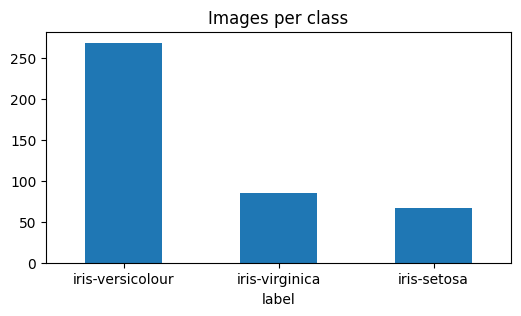

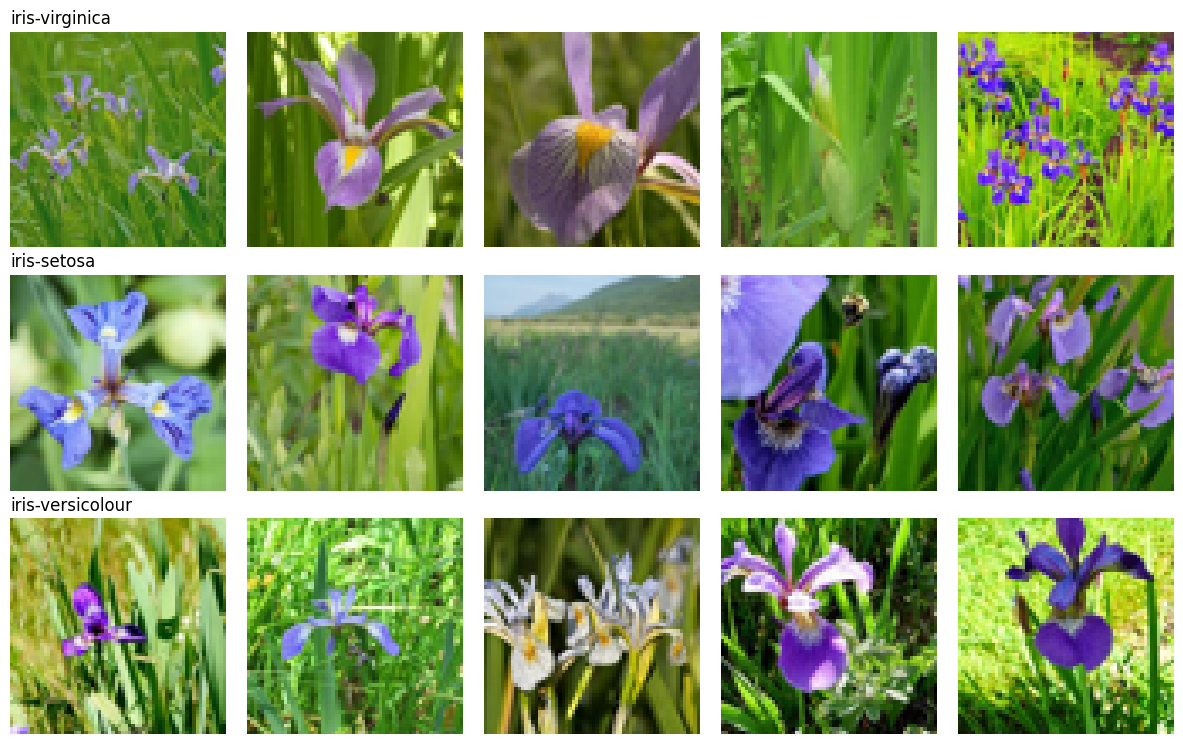

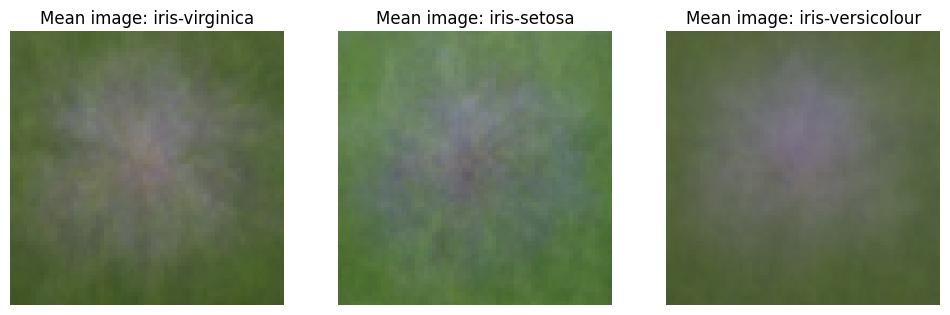

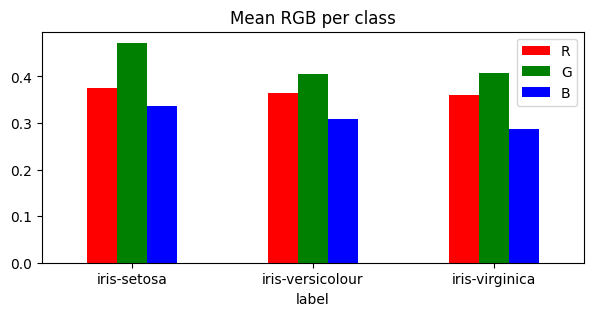

In [ ]:
# ============================================
# 2단계(계속): 이미지 데이터의 특성 분석
# ============================================
import matplotlib.pyplot as plt

# (1) 클래스 분포 (데이터 균형 확인)
img_df['label'].value_counts().plot(kind='bar', figsize=(6, 3), rot=0, #.plot(kind='bar', ...): 이 개수를 막대그래프(bar)로 시각화. rot=0은 x축 라벨(품종 이름)을 회전시키지 않도록 설정
                                    title='Images per class')
plt.show()

# (2) 품종별 샘플 이미지 확인
fig, axes = plt.subplots(len(class_names), 5, figsize=(12, 2.5*len(class_names)))
for r, cls in enumerate(class_names):
    cls_idx = np.where(y_img == r)[0][:5] #cls_idx = np.where(y_img == r)[0][:5]: y_img에서 현재 품종(r)에 해당하는 이미지들의 인덱스를 찾고, 그중 앞에서 5개만 선택합니다.
    for c, i in enumerate(cls_idx):
        axes[r, c].imshow(X_img[i]); axes[r, c].axis('off') #axis('off')는 축 라벨을 제거하여 이미지만 깔끔하게 보이도록 합니다.
        if c == 0: axes[r, c].set_title(cls, loc='left') # 각 품종 행의 첫 번째 이미지 위에 해당 품종의 이름을 제목으로 표시합니다.
plt.tight_layout(); plt.show()

# (3) 품종별 '평균 이미지' — CSV의 describe()에 해당하는 분석
fig, axes = plt.subplots(1, len(class_names), figsize=(4*len(class_names), 4))
for r, cls in enumerate(class_names):
    axes[r].imshow(X_img[y_img == r].mean(axis=0)) # X_img[y_img == r].mean(axis=0): 현재 품종(r)에 해당하는 모든 이미지들을 X_img에서 선택한 후, axis=0을 기준으로 평균을 계산합니다. 즉, 같은 위치의 픽셀 값들을 모두 평균 내어 '평균적인 이미지'를 만듭니다.
    axes[r].set_title(f'Mean image: {cls}'); axes[r].axis('off')
plt.show()

# (4) 품종별 평균 RGB 값 — 색상이 구분 특성이 될 수 있는가?
mean_rgb = pd.DataFrame(X_img.reshape(len(X_img), -1, 3).mean(axis=1), #(이미지 수, 높이, 너비, 채널) 형태의 X_img 배열을 (이미지 수, 모든 픽셀 수, 채널) 형태로 변환합니다. -1은 NumPy가 자동으로 적절한 크기를 계산하도록 합니다.
                                                                      #이렇게 하면 각 이미지의 모든 픽셀에 대한 RGB 값을 쉽게 다룰 수 있습니다.
                        columns=['R', 'G', 'B'])
mean_rgb['label'] = img_df['label'].values
mean_rgb.groupby('label').mean().plot(kind='bar', figsize=(7, 3), rot=0, #품종별로 그룹화하여 각 품종의 평균 R, G, B 값을 계산합니다.
    color=['red', 'green', 'blue'], title='Mean RGB per class')
plt.show()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,299 (669.14 KB)

 Trainable params: 171,299 (669.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.5933 - loss: 0.9938 - val_accuracy: 0.6912 - val_loss: 0.8859
Epoch 2/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.6306 - loss: 0.9343 - val_accuracy: 0.6912 - val_loss: 0.8544
Epoch 3/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.6269 - loss: 0.9227 - val_accuracy: 0.6912 - val_loss: 0.8508
Epoch 4/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.6269 - loss: 0.9219 - val_accuracy: 0.6912 - val_loss: 0.8535
Epoch 5/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.6269 - loss: 0.9088 - val_accuracy: 0.6912 - val_loss: 0.8702
Epoch 6/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.6269 - loss: 0.9141 - val_accuracy: 0.6912 - val_loss: 0.8657
Epoch 7/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - accuracy: 0.6231 - loss: 0.9039 - val_accuracy: 0.6912 - val_loss: 0.8275
Epoch 8/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.6231 - loss: 0.8834 - val_accuracy: 0.6912 - val_loss: 0.86

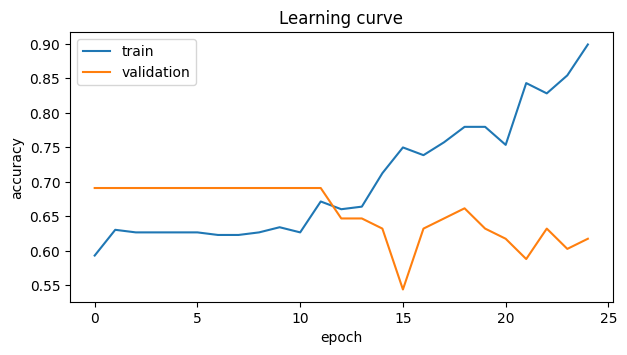

★ 테스트 정확도: 0.5647


In [ ]:
# ============================================
# 3단계: CNN(합성곱 신경망) 모델 학습 → 정확도 평가
#  - 이미지는 픽셀에서 특성을 '스스로 추출'해야 하므로 CNN이 적합
# ============================================
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# 훈련:테스트 = 8:2 분할 (stratify로 클래스 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X_img, y_img, test_size=0.2, random_state=42, stratify=y_img)

# CNN 모델 구성 (3개의 Conv+MaxPool 블록 → 특성 추출, 크기 축소)
model_cnn = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    # Conv 블록 1
    layers.Conv2D(16, 3, activation='relu'),  # 16개 필터로 저수준 특성 감지
    layers.MaxPooling2D(),  # 2×2로 압축
    # Conv 블록 2
    layers.Conv2D(32, 3, activation='relu'),  # 32개 필터로 중간 수준 특성
    layers.MaxPooling2D(),
    # Conv 블록 3
    layers.Conv2D(64, 3, activation='relu'),  # 64개 필터로 고수준 특성
    layers.MaxPooling2D(),
    # 분류기 (Fully Connected)
    layers.Flatten(),  # 2D → 1D 벡터로 변환
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),  # 30% 뉴런 랜덤 비활성화 (과대적합 방지)
    layers.Dense(len(class_names), activation='softmax'),  # 클래스 확률 출력
])
model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',  # 정수 레이블 사용
                  metrics=['accuracy'])
model_cnn.summary()

# 학습 (훈련 데이터의 20%를 검증 데이터로 사용하여 매 epoch마다 성능 모니터링)
history = model_cnn.fit(X_train, y_train,
                        validation_split=0.2,
                        epochs=25, batch_size=32, verbose=1)

# 학습 곡선 → 과대적합 여부를 눈으로 확인
# train과 validation의 gap이 크면 과대적합, 좁으면 좋은 모델
plt.figure(figsize=(7, 3.5))
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend()
plt.title('Learning curve'); plt.show()

# 최종 테스트 정확도 (학습에 사용되지 않은 데이터에서의 성능)
test_loss, test_acc = model_cnn.evaluate(X_test, y_test, verbose=0)
print(f"★ 테스트 정확도: {test_acc:.4f}")  # 0.0~1.0 사이의 값

## CNN(합성곱 신경망) 모델 학습

### 0. 왜 CNN인가?

앞서 사용한 랜덤 포레스트는 **표 형태의 데이터**(꽃받침 길이, 너비 …)처럼 사람이 미리 특성을 정해준 데이터에 적합합니다.
하지만 이미지는 특성이 미리 주어지지 않습니다. $64 \times 64$ 컬러 이미지 하나는 $64 \times 64 \times 3 = 12{,}288$ 개의 숫자 덩어리일 뿐입니다.

| | 일반 신경망(Dense만 사용) | CNN |
|---|---|---|
| 입력 처리 | 픽셀을 일렬로 펴서 취급 | 2차원 위치 관계를 유지 |
| 문제점 | 픽셀이 조금만 밀려도 완전히 다른 입력으로 인식 | 위치가 달라도 같은 패턴을 인식 |
| 파라미터 수 | 매우 많음 | 필터를 공유하므로 적음 |

> **핵심**: CNN은 "어디에 있든 이런 모양이 보이면 반응하는" 필터를 스스로 학습합니다.

---

### 1. 데이터 분할

```python
X_train, X_test, y_train, y_test = train_test_split(
    X_img, y_img, test_size=0.2, random_state=42, stratify=y_img)
```

| 인자 | 의미 |
|---|---|
| `test_size=0.2` | 전체의 20%를 **테스트용**으로 떼어 놓음 (학습에 절대 사용 안 함) |
| `random_state=42` | 난수 고정 → 실행할 때마다 같은 결과 (재현성) |
| `stratify=y_img` | 각 클래스 비율을 훈련/테스트에 **동일하게** 유지 |

`stratify`가 없으면 우연히 특정 클래스가 테스트셋에 몰려 정확도가 왜곡될 수 있습니다.

---

### 2. 모델 구조

```python
layers.Conv2D(16, 3, activation='relu')
layers.MaxPooling2D()
```

#### (가) `Conv2D` — 합성곱 층

$3 \times 3$ 크기의 작은 창(**필터/커널**)을 이미지 위로 한 칸씩 미끄러뜨리며, 겹쳐진 부분끼리 곱해서 더합니다.

- **`16`** = 필터 개수. 서로 다른 16가지 패턴을 동시에 찾습니다.
- **`3`** = 필터 크기 $3 \times 3$
- 출력 크기: $H_{out} = H_{in} - k + 1$ (여기서 $k=3$, padding 없음)

한 필터가 통과하면 **특성 맵(feature map)** 한 장이 나옵니다. 필터가 16개면 16장이 쌓입니다.

#### (나) `activation='relu'`

$$\text{ReLU}(x) = \max(0,\ x)$$

음수는 0으로, 양수는 그대로. 이 **비선형** 처리가 없으면 층을 아무리 쌓아도 결국 하나의 선형식으로 축약되어 복잡한 패턴을 배울 수 없습니다.

#### (다) `MaxPooling2D` — 풀링 층

$2 \times 2$ 영역에서 **가장 큰 값 하나만** 남깁니다. 가로·세로가 절반이 됩니다.

- 계산량 감소
- 위치가 조금 흔들려도 같은 결과 → **위치 변화에 둔감**해짐

#### (라) 왜 16 → 32 → 64로 늘어나는가?

층이 깊어질수록 이미지 **해상도는 줄고**, 대신 **더 복잡한 패턴**을 담당합니다.

| 블록 | 공간 크기 | 필터 수 | 감지하는 것 |
|---|---|---|---|
| 1 | 큼 | 16 | 경계선, 밝기 변화 |
| 2 | 중간 | 32 | 모서리, 단순 도형 |
| 3 | 작음 | 64 | 질감, 부분 형태 |

---

### 3. 분류기 부분

```python
layers.Flatten()
layers.Dense(64, activation='relu')
layers.Dropout(0.3)
layers.Dense(len(class_names), activation='softmax')
```

| 층 | 역할 |
|---|---|
| `Flatten` | 3차원 특성 맵을 1차원 벡터로 펼침 (여기서부터 일반 신경망) |
| `Dense(64)` | 추출된 특성들을 조합해 판단 |
| `Dropout(0.3)` | 학습 중 뉴런의 30%를 **무작위로 꺼서** 특정 뉴런에 의존하지 않게 함 → 과대적합 억제 |
| `Dense(n, softmax)` | 클래스 개수만큼 출력, 합이 1인 **확률**로 변환 |

`Dropout`은 **학습할 때만** 작동하고, 예측·평가 시에는 자동으로 꺼집니다.

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

---

### 4. 컴파일 설정

```python
model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
```

| 인자 | 의미 |
|---|---|
| `optimizer='adam'` | 오차를 줄이는 방향으로 가중치를 수정하는 알고리즘. 학습률을 자동 조절해 무난함 |
| `loss=...` | 예측이 정답과 얼마나 다른지 재는 **손실 함수**. 학습은 이 값을 줄이는 과정 |
| `metrics=['accuracy']` | 사람이 보기 위한 지표. 학습 자체에는 관여하지 않음 |

> **`sparse_` 가 붙은 이유**: 정답이 `0, 1, 2` 같은 **정수**일 때 사용합니다.
> 정답이 `[0,1,0]` 같은 원-핫 벡터라면 `categorical_crossentropy`를 씁니다.

---

### 5. 학습

```python
history = model_cnn.fit(X_train, y_train,
                        validation_split=0.2,
                        epochs=25, batch_size=32, verbose=1)
```

| 인자 | 의미 |
|---|---|
| `validation_split=0.2` | 훈련 데이터 중 20%를 **검증용**으로 분리. 매 epoch마다 "처음 보는 데이터" 성능 확인 |
| `epochs=25` | 전체 훈련 데이터를 25번 반복 학습 |
| `batch_size=32` | 32장씩 묶어서 가중치를 한 번 수정 |

데이터가 세 갈래로 나뉜 점을 정리하면 다음과 같습니다.

| 이름 | 비율(전체 기준) | 용도 |
|---|---|---|
| 훈련 | 64% | 가중치를 실제로 수정 |
| 검증 | 16% | 학습 중 과대적합 감시 |
| 테스트 | 20% | 맨 마지막에 딱 한 번, 최종 성능 측정 |

---

### 6. 학습 곡선 읽는 법

```python
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
```

`history`에는 epoch별 기록이 저장되어 있습니다. 두 곡선의 관계로 모델 상태를 진단합니다.

| 그래프 모양 | 진단 | 대응 |
|---|---|---|
| 두 곡선이 함께 상승, 간격 좁음 | **정상** | 그대로 사용 |
| train은 계속 오르는데 validation은 정체·하락 | **과대적합** | Dropout 강화, 데이터 증강, epoch 축소 |
| 둘 다 낮은 상태로 정체 | **과소적합** | 층·필터 추가, epoch 증가 |

> 과대적합은 "훈련 데이터를 외워버린" 상태입니다. 시험 범위를 통째로 암기했지만 응용 문제를 못 푸는 것과 같습니다.

---

Saving test_image.jfif to test_image.jfif


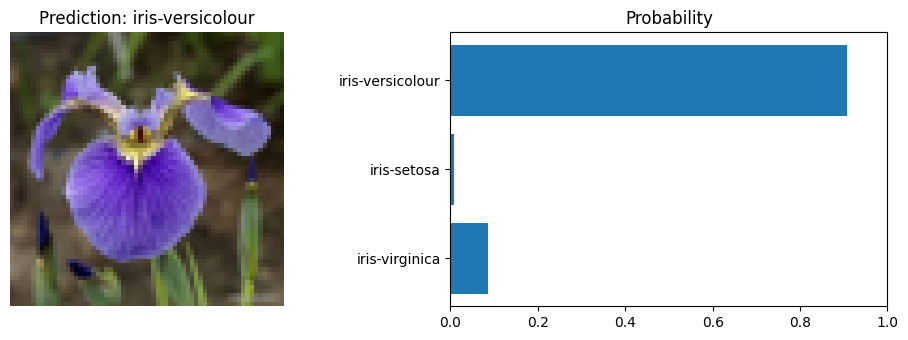

iris-virginica: 8.5%
iris-setosa: 0.8%
iris-versicolour: 90.7%


In [12]:
# ============================================
# 4단계: 새로운 붓꽃 사진을 업로드하여 모델 동작 확인
# ============================================
from google.colab import files
from PIL import Image  # img 처리에 필요 (앞 단계에서 import 했다면 생략 가능)

# 인터넷에서 받은 붓꽃 사진(jpg/png) 업로드
# 제공된 test_image.jfif 은 setosa 사진임
uploaded = files.upload()          # 실행 시 파일 선택 창이 뜸
fname = list(uploaded.keys())[0]   # 업로드된 파일 중 첫 번째의 '파일명'만 추출

# 학습 때와 '완전히 동일한' 전처리를 적용해야 한다 ← 중요 포인트!
img = (Image.open(fname)
       .convert('RGB')                    # 흑백·투명도(RGBA) 이미지도 3채널로 통일
       .resize((IMG_SIZE, IMG_SIZE)))     # 모델 입력 크기에 맞게 강제 리사이즈

x_new = np.array(img)[np.newaxis] / 255.0
# [np.newaxis] : (64,64,3) → (1,64,64,3)  맨 앞에 '배치 차원' 추가
# / 255.0      : 0~255 픽셀값을 0~1로 정규화 (학습 때와 동일해야 함)

proba = model_cnn.predict(x_new, verbose=0)[0]   # [0] : 배치 1개이므로 첫 결과만 꺼냄
pred_cls = class_names[np.argmax(proba)]         # argmax : 확률이 가장 큰 칸의 '번호'

# 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))  # 1행 2열 (사진 | 막대그래프)
axes[0].imshow(img); axes[0].axis('off')           # 왼쪽: 업로드한 사진
axes[0].set_title(f'Prediction: {pred_cls}')
axes[1].barh(class_names, proba)                   # 오른쪽: 클래스별 확률 가로 막대
axes[1].set_xlim(0, 1); axes[1].set_title('Probability')  # 축을 0~1로 고정해야 비교 가능
plt.tight_layout(); plt.show()

for c, p in zip(class_names, proba):
    print(f"{c}: {p:.1%}")   # .1% : 0.8342 → '83.4%' 로 자동 변환

## 다시한번 설명

학습한 모델이 **실제로 쓸 만한지** 확인하는 단계입니다. 테스트 정확도는 숫자일 뿐이므로, 직접 구한 사진 한 장을 넣어 보는 것이 가장 직관적인 검증입니다.

---

### 1. 파일 업로드

```python
uploaded = files.upload()
fname = list(uploaded.keys())[0]
```

`files.upload()`는 코랩 전용 기능으로, 실행하면 셀 아래에 **파일 선택 버튼**이 나타납니다.

반환값 `uploaded`는 딕셔너리입니다.

| | 내용 |
|---|---|
| 키(key) | 파일 이름 (예: `'test_image.jfif'`) |
| 값(value) | 파일의 실제 내용 (바이트) |

여기서는 파일 이름만 필요하므로 `list(uploaded.keys())[0]`으로 **첫 번째 키**를 꺼냅니다.

> 업로드된 파일은 코랩 가상 서버에 임시 저장되며, 런타임이 끊기면 사라집니다.

---

### 2. 전처리 — 이 단계의 핵심

```python
img = (Image.open(fname)
       .convert('RGB')
       .resize((IMG_SIZE, IMG_SIZE)))
```

모델은 **학습할 때 본 형태의 입력만** 제대로 처리합니다. 따라서 세 가지를 맞춰야 합니다.

| 항목 | 이유 |
|---|---|
| `.convert('RGB')` | 흑백(1채널)이나 투명도가 있는 PNG(4채널)를 3채널로 통일. 모델 입력은 `(64, 64, 3)`으로 고정되어 있음 |
| `.resize(...)` | 인터넷 사진은 크기가 제각각이므로 학습 때와 같은 크기로 축소 |
| `/ 255.0` | 학습 데이터를 0~1로 정규화했다면 여기서도 똑같이 해야 함 |

> `.jfif`는 JPEG의 변종 확장자입니다. `Image.open()`이 확장자가 아닌 파일 내부 형식을 보고 판단하므로 그대로 열립니다.

#### `np.newaxis` — 배치 차원 추가

```python
x_new = np.array(img)[np.newaxis] / 255.0
```

신경망은 항상 **여러 장을 한 번에** 처리하도록 만들어져 있어, 입력이 4차원이어야 합니다.

$$(64,\ 64,\ 3) \xrightarrow{\ \text{np.newaxis}\ } (1,\ 64,\ 64,\ 3)$$

맨 앞의 `1`이 "사진 1장"을 뜻합니다. 이 차원이 없으면 형태 불일치 오류가 납니다.

---

### 3. 예측 결과 해석

```python
proba = model_cnn.predict(x_new, verbose=0)[0]
pred_cls = class_names[np.argmax(proba)]
```

`predict()`의 결과는 `(1, 클래스 수)` 모양입니다. 사진이 1장이므로 `[0]`으로 첫 줄만 꺼냅니다.

`proba`는 softmax를 거친 **확률 배열**입니다. 예를 들어 클래스가 3개라면,

```
proba = [0.92, 0.05, 0.03]   ← 합은 항상 1
```

| 함수 | 반환값 | 예시 |
|---|---|---|
| `np.argmax(proba)` | 가장 큰 값의 **위치(인덱스)** | `0` |
| `np.max(proba)` | 가장 큰 **값 자체** | `0.92` |

인덱스를 `class_names`에 넣어야 비로소 이름이 됩니다.

> 확률이 가장 높다고 해서 정답은 아닙니다. `[0.38, 0.34, 0.28]`처럼 고르게 퍼져 있다면 모델이 **판단을 못 하고 있다**는 신호입니다. 막대그래프를 함께 그리는 이유가 여기에 있습니다.

---

### 4. 그래프 관련

| 구문 | 역할 |
|---|---|
| `plt.subplots(1, 2, ...)` | 그림 영역을 1행 2열로 나눔. `axes[0]`, `axes[1]`로 각각 접근 |
| `axes[0].imshow(img)` | 이미지를 그대로 표시 |
| `axes[0].axis('off')` | 사진 주변의 눈금·축 제거 |
| `barh(...)` | **가로** 막대그래프. 클래스 이름이 길 때 세로보다 읽기 편함 |
| `set_xlim(0, 1)` | 축 범위를 0~1로 고정. 이걸 안 하면 확률이 낮아도 막대가 꽉 차 보여 오해를 부름 |
| `plt.tight_layout()` | 제목·축 이름이 겹치지 않도록 여백 자동 조정 |

#### `:.1%` 포맷

```python
print(f"{c}: {p:.1%}")
```

소수를 **백분율로 자동 변환**하고 소수점 첫째 자리까지 표시합니다.

| 원래 값 | 출력 |
|---|---|
| `0.8342` | `83.4%` |
| `0.05` | `5.0%` |

$100$을 곱하고 `%`를 붙이는 과정이 한 번에 처리됩니다.